# Tissue foreground & tumour-area estimation from cellular tables

Several benchmark baselines want a **physical density** (cells per mm^2) rather than a raw
count or a fraction - e.g. a *CD8 T-cell density baseline of ~2,000 / mm^2*. A density needs
a denominator: the **tissue area** of each region. We do not have the raw images here, only
the per-cell tables (`coordinates.csv`, `expression.csv`, `cell_types.csv`), so we
**estimate the tissue foreground from the cell centroids**.

This notebook:

1. builds a binary **tissue-foreground mask** for a region from its cell centroids
   (occupancy grid -> morphological close -> fill holes -> drop debris specks);
2. converts the mask to a compact **polygon (GeoJSON MultiPolygon, with holes)**;
3. curates, **for every dataset, which cell-type labels are tumour cells**;
4. builds a **tumour sub-mask / sub-polygon** from the tumour cells - the tumour
   *compartment*, which by construction still **encloses the immune and other cells that sit
   inside tumour nests**.

All geometry is kept in the **same coordinate space as `coordinates.csv`** (pixels for most
datasets) and carries `microns_per_pixel`, so areas convert to um^2/mm^2 exactly the way
`RegionData.coordinates` does. The tumour sub-mask is built on the **same grid** as the
tissue mask and clipped to it, so tumour area <= tissue area and both align cell-for-cell.

## 0. Setup

In [ ]:
import sys, json
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.spatial import ConvexHull

data_root = Path(".").resolve().parent.parent
code_root = Path(".").resolve().parent
sys.path.insert(0, str(code_root))

from benchmark.utils.registry import load_dataset, list_datasets
list_datasets()

['bc_jackson2020',
 'bc_metabric_ali2020',
 'crc_schurch2020',
 'crc_wu2022',
 'hnc_wu2022',
 'luad_sorin2023',
 'nsclc_aung2025',
 'nsclc_gnn_hoebel2026',
 'nsclc_ici_monkman2024',
 'tnbc_wang2023']

## 1. Load a region and look at the point cloud

We use **NSCLC-Aung2025** as the worked example. The cell centroids already trace out the
tissue: the empty band around the cells is background (no tissue / no segmentation), and
that is exactly what we want to *exclude* from the area denominator.

dataset           : NSCLC-Aung2025
region            : UQ_A1
n_cells           : 4946
microns_per_pixel : 1.0
x range (px)      : 188 .. 1218
y range (px)      : 139 .. 1261


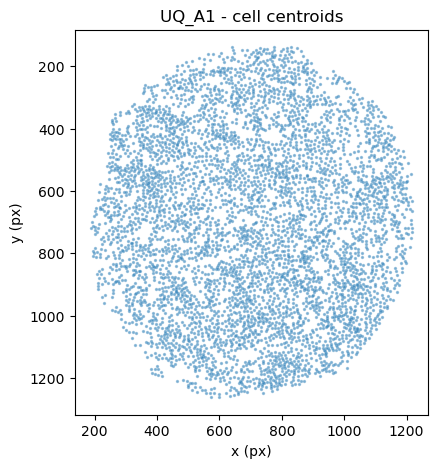

In [4]:
ds = load_dataset("nsclc_aung2025", data_root=data_root)
rid = ds.all_region_ids[0]
reg = ds.load_region(rid, normalize=False)
mpp = reg.microns_per_pixel
xy = reg.coordinates[["x", "y"]].to_numpy(float)

print(f"dataset           : {ds.name}")
print(f"region            : {rid}")
print(f"n_cells           : {reg.n_cells}")
print(f"microns_per_pixel : {mpp}")
print(f"x range (px)      : {xy[:,0].min():.0f} .. {xy[:,0].max():.0f}")
print(f"y range (px)      : {xy[:,1].min():.0f} .. {xy[:,1].max():.0f}")

plt.figure(figsize=(5, 5))
plt.scatter(xy[:, 0], xy[:, 1], s=2, alpha=0.4)
plt.gca().set_aspect("equal"); plt.gca().invert_yaxis()
plt.title(f"{rid} - cell centroids"); plt.xlabel("x (px)"); plt.ylabel("y (px)")
plt.show()

## 2. The core estimator: occupancy grid -> tissue mask

The idea is deliberately simple and robust (no image, no training):

1. **Occupancy grid** - bin the centroids into square bins of side `bin_um` microns; a bin
   is *seeded* if it contains >=1 cell.
2. **Morphological closing** (radius ~ `close_um`) - bridge the small gaps *between* cells
   so contiguous tissue becomes one solid region. The closing radius should exceed the
   typical inter-cell spacing (~ `1/sqrt(local density)`), which is ~15-20 um here.
3. **Fill holes** - fill enclosed gaps (lumina, vessels) so they count as tissue. Set
   `fill_holes=False` if you instead want lumina excluded.
4. **Drop specks** - remove tiny disconnected components (stray cells / debris) below
   `min_component_mm2`.
5. **Scattered-cell fallback** - if after all of the above the mask covers fewer than
   `min_covered_frac` of the cells (or is empty), the region is just scattered cells with no
   real bulk; steps 2-4 would leave a spuriously tiny area, so we fall back to a naive
   **convex-hull envelope** of the cells (bounding box if the hull is degenerate).

`bin_um` trades boundary tightness vs hole-robustness; we sweep it in section 3 to show the
area is stable. The mask is stored on a small grid with its world-space origin so it maps
back exactly onto the cell coordinates.

The grid is **zero-padded** before the morphology runs. Without it, closing's erosion step
and `fill_holes` treat everything outside the array as background, which chews away any
tissue sitting on the grid edge (a whole edge row/column can vanish). Padding wider than the
closing radius keeps edge tissue intact; we crop back and shift the origin so nothing moves.

In [5]:
@dataclass
class TissueMask:
    """Binary tissue-foreground mask on a coarse grid, in the region's coordinate space.

    ``mask[iy, ix]`` is True where there is tissue. Bin ``(ix, iy)`` covers the world
    (pixel-coordinate) box ``[x0 + ix*bin_px, x0 + (ix+1)*bin_px) x
    [y0 + iy*bin_px, y0 + (iy+1)*bin_px)``. ``bin_px`` is the bin side in coordinate
    (pixel) units; ``bin_um`` the same in microns; ``microns_per_pixel`` ties the two.
    """
    mask: np.ndarray          # bool [ny, nx]
    x0: float
    y0: float
    bin_px: float
    bin_um: float
    microns_per_pixel: float

    @property
    def n_tissue_bins(self) -> int:
        return int(self.mask.sum())

    @property
    def area_um2(self) -> float:
        return self.n_tissue_bins * (self.bin_um ** 2)

    @property
    def area_mm2(self) -> float:
        return self.area_um2 / 1e6

    def contains(self, xy: np.ndarray) -> np.ndarray:
        """Boolean: which of the given world (pixel) coordinates fall inside the tissue."""
        ix = np.floor((xy[:, 0] - self.x0) / self.bin_px).astype(int)
        iy = np.floor((xy[:, 1] - self.y0) / self.bin_px).astype(int)
        ny, nx = self.mask.shape
        inb = (ix >= 0) & (iy >= 0) & (ix < nx) & (iy < ny)
        out = np.zeros(len(xy), bool)
        out[inb] = self.mask[iy[inb], ix[inb]]
        return out


def occupancy_grid(xy, microns_per_pixel, bin_um):
    """Count cells per square bin. Returns (counts[ny,nx], (x0, y0, bin_px))."""
    bin_px = bin_um / microns_per_pixel
    x0, y0 = xy.min(axis=0) - bin_px          # one-bin margin so the border isn't clipped
    nx = int(np.ceil((xy[:, 0].max() - x0) / bin_px)) + 2
    ny = int(np.ceil((xy[:, 1].max() - y0) / bin_px)) + 2
    ix = ((xy[:, 0] - x0) / bin_px).astype(int)
    iy = ((xy[:, 1] - y0) / bin_px).astype(int)
    counts = np.zeros((ny, nx), int)
    np.add.at(counts, (iy, ix), 1)
    return counts, (x0, y0, bin_px)


def _grid_covers(occ, xy, x0, y0, bin_px):
    """Fraction of points whose bin is True in ``occ`` (points inside the mask)."""
    ny, nx = occ.shape
    ix = np.floor((xy[:, 0] - x0) / bin_px).astype(int)
    iy = np.floor((xy[:, 1] - y0) / bin_px).astype(int)
    inb = (ix >= 0) & (iy >= 0) & (ix < nx) & (iy < ny)
    inside = np.zeros(len(xy), bool)
    inside[inb] = occ[iy[inb], ix[inb]]
    return inside.mean() if len(xy) else 0.0


def _envelope_mask(xy, x0, y0, bin_px, shape):
    """Naive envelope of the points on the given grid: convex hull, bbox if degenerate."""
    ny, nx = shape
    xs = x0 + (np.arange(nx) + 0.5) * bin_px
    ys = y0 + (np.arange(ny) + 0.5) * bin_px
    gx, gy = np.meshgrid(xs, ys)
    try:
        from scipy.spatial import ConvexHull
        from matplotlib.path import Path as _Path
        verts = xy[ConvexHull(xy).vertices]
        inside = _Path(verts).contains_points(
            np.column_stack([gx.ravel(), gy.ravel()])).reshape(ny, nx)
        if inside.any():
            return inside
    except Exception:
        pass
    # degenerate (<3 points or collinear): fall back to the point bounding box
    return ((gx >= xy[:, 0].min()) & (gx <= xy[:, 0].max()) &
            (gy >= xy[:, 1].min()) & (gy <= xy[:, 1].max())).reshape(ny, nx)


def estimate_tissue_mask(xy, microns_per_pixel, *, bin_um=25.0, close_um=50.0,
                         min_seed_count=1, fill_holes=True, min_component_mm2=0.01,
                         fallback_envelope=True, min_covered_frac=0.5):
    """Estimate the tissue-foreground mask from cell centroids (see section 2).

    When the cells are only *scattered* (no real bulk) the morphology + small-component
    drop can shrink the mask to almost nothing, badly under-sizing the tissue. If the mask
    ends up covering fewer than ``min_covered_frac`` of the cells (or is empty), we fall
    back to a naive **convex-hull envelope** of all cells (bounding box if degenerate) so
    the area isn't spuriously tiny. Set ``fallback_envelope=False`` to disable.
    """
    counts, (x0, y0, bin_px) = occupancy_grid(xy, microns_per_pixel, bin_um)
    occ = counts >= min_seed_count

    radius_bins = max(1, int(round(close_um / bin_um)))

    # Zero-pad wider than the morphology reach. scipy's closing (its erosion step)
    # and fill_holes (its border flood-fill) treat outside-the-array as background,
    # so tissue sitting on the grid edge would otherwise be eroded/clipped away
    # ("edge effect"). Padding keeps real tissue >= radius_bins from the border, then
    # we crop back and shift the origin so coordinates are unchanged.
    pad = radius_bins + 1
    occ = np.pad(occ, pad, mode="constant", constant_values=False)
    x0 -= pad * bin_px
    y0 -= pad * bin_px

    structure = ndi.generate_binary_structure(2, 1)
    occ = ndi.binary_closing(occ, structure=structure, iterations=radius_bins)
    if fill_holes:
        occ = ndi.binary_fill_holes(occ)

    if min_component_mm2 and occ.any():
        min_bins = max(1, int(min_component_mm2 * 1e6 / (bin_um ** 2)))
        lbl, n = ndi.label(occ)
        if n > 1:
            sizes = np.bincount(lbl.ravel())
            sizes[0] = 0
            keep = np.where(sizes >= min_bins)[0]
            occ = np.isin(lbl, keep)

    # Scattered-cell fallback: if the mask captured too few cells, use a naive envelope.
    if fallback_envelope and len(xy) and (
            not occ.any() or _grid_covers(occ, xy, x0, y0, bin_px) < min_covered_frac):
        occ = _envelope_mask(xy, x0, y0, bin_px, occ.shape)

    return TissueMask(occ, float(x0), float(y0), float(bin_px),
                      float(bin_um), float(microns_per_pixel))

grid shape   : (54, 51)  (ny, nx)
tissue bins  : 1509
area         : 0.943 mm2  (943,125 um2)
cells inside : 4946 / 4946


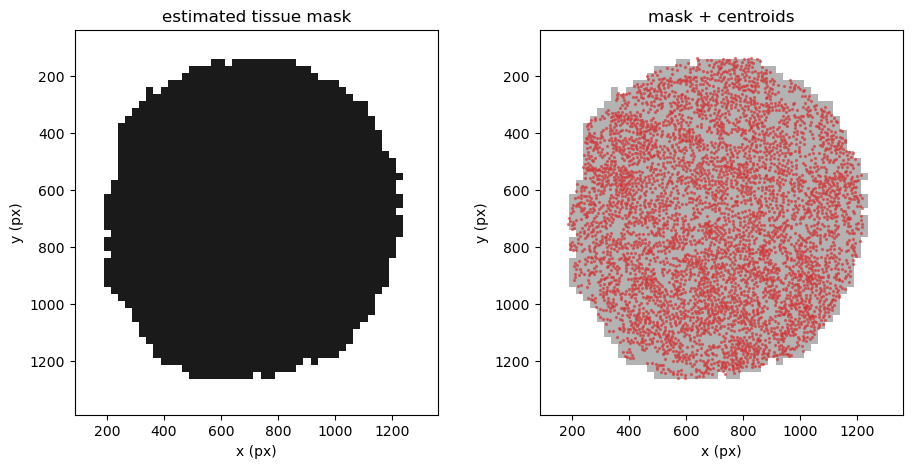

In [6]:
tm = estimate_tissue_mask(xy, mpp, bin_um=25.0, close_um=50.0)
print(f"grid shape   : {tm.mask.shape}  (ny, nx)")
print(f"tissue bins  : {tm.n_tissue_bins}")
print(f"area         : {tm.area_mm2:.3f} mm2  ({tm.area_um2:,.0f} um2)")
print(f"cells inside : {tm.contains(xy).sum()} / {len(xy)}")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
extent = [tm.x0, tm.x0 + tm.mask.shape[1] * tm.bin_px,
          tm.y0 + tm.mask.shape[0] * tm.bin_px, tm.y0]   # y inverted
ax[0].imshow(tm.mask, extent=extent, cmap="Greys", alpha=0.9, origin="upper")
ax[0].set_title("estimated tissue mask")
ax[1].imshow(tm.mask, extent=extent, cmap="Greys", alpha=0.3, origin="upper")
ax[1].scatter(xy[:, 0], xy[:, 1], s=2, alpha=0.5, c="tab:red")
ax[1].set_title("mask + centroids")
for a in ax:
    a.set_aspect("equal"); a.set_xlabel("x (px)"); a.set_ylabel("y (px)")
plt.show()

**Scattered-cell fallback in action.** A synthetic region of ~40 cells sprinkled at random:
the occupancy+morphology mask collapses (each cell is its own speck, all dropped), which would
report an almost-zero area. With `fallback_envelope=True` the estimator instead returns the
convex-hull envelope, giving a sensible tissue size.

no fallback : 0.0000 mm2  (cells inside 0/40)
envelope    : 0.4512 mm2  (cells inside 32/40)


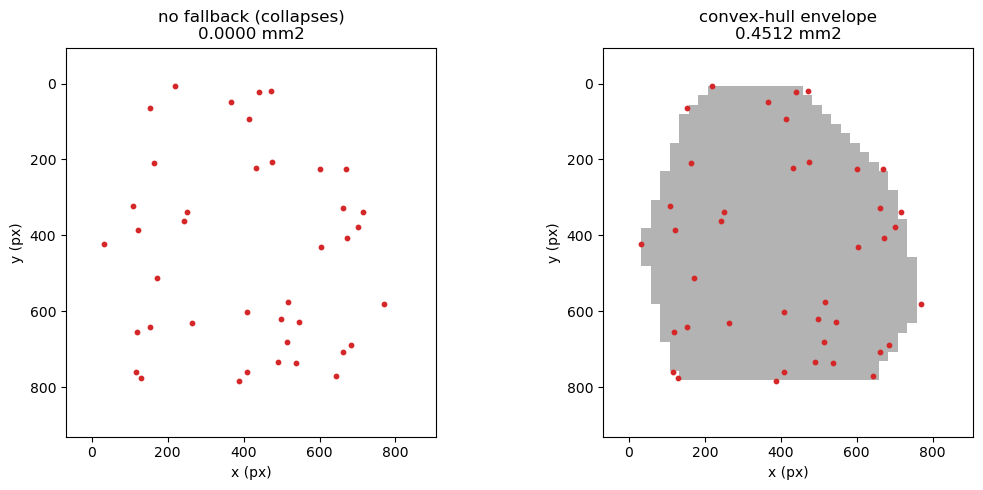

In [7]:
rng_demo = np.random.default_rng(1)
scatter_xy = rng_demo.uniform([0, 0], [800, 800], size=(40, 2))

tm_none = estimate_tissue_mask(scatter_xy, 1.0, fallback_envelope=False)
tm_env  = estimate_tissue_mask(scatter_xy, 1.0, fallback_envelope=True)
print(f"no fallback : {tm_none.area_mm2:.4f} mm2  (cells inside {tm_none.contains(scatter_xy).sum()}/{len(scatter_xy)})")
print(f"envelope    : {tm_env.area_mm2:.4f} mm2  (cells inside {tm_env.contains(scatter_xy).sum()}/{len(scatter_xy)})")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for a, m, ttl in zip(ax, [tm_none, tm_env], ["no fallback (collapses)", "convex-hull envelope"]):
    ext = [m.x0, m.x0 + m.mask.shape[1]*m.bin_px, m.y0 + m.mask.shape[0]*m.bin_px, m.y0]
    a.imshow(m.mask, extent=ext, cmap="Greys", alpha=0.3, origin="upper")
    a.scatter(scatter_xy[:, 0], scatter_xy[:, 1], s=10, c="tab:red")
    a.set_aspect("equal"); a.set_xlabel("x (px)"); a.set_ylabel("y (px)")
    a.set_title(f"{ttl}\n{m.area_mm2:.4f} mm2")
plt.tight_layout(); plt.show()

## 3. Sensitivity to bin size

A good estimator shouldn't depend strongly on the bin choice. Across 15-60 um the area moves
only a few percent and the all-cell density stays in a tight band - `bin_um=25` is a sensible
default (small enough to follow the boundary, large enough that interior bins are reliably
seeded). The convex hull is shown as an upper bound; for concave / multi-piece tissue it
overestimates badly, which is the whole reason we use the occupancy mask instead.

In [8]:
rows = []
for bu in [15, 20, 25, 30, 40, 60]:
    m = estimate_tissue_mask(xy, mpp, bin_um=bu)
    rows.append({"bin_um": bu, "area_mm2": m.area_mm2,
                 "all_cell_density_per_mm2": len(xy) / m.area_mm2})
hull = ConvexHull(xy)
hull_mm2 = hull.volume * mpp**2 / 1e6   # 2-D: .volume is the polygon area
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))
print(f"\nconvex-hull area (upper bound): {hull_mm2:.3f} mm2")

 bin_um  area_mm2  all_cell_density_per_mm2
     15  0.915975               5399.710691
     20  0.929200               5322.858373
     25  0.943125               5244.267727
     30  0.951300               5199.201093
     40  0.976000               5067.622951
     60  1.015200               4871.946414

convex-hull area (upper bound): 0.920 mm2


## 4. Mask -> polygon (compact, with holes)

A full grid is wasteful to store and awkward to overlay. We trace the mask boundary with
**marching squares** (`skimage.measure.find_contours` at level 0.5) into a **GeoJSON
`MultiPolygon`**: each tissue component is one outer ring plus zero or more hole rings (only
present when `fill_holes=False`). Marching squares follows *bin edges*, so a run of occupied
bins is enclosed fully and symmetrically - unlike a bin-centre trace, which clips the far
(large-x/large-y) side by a bin. Vertices are simplified (Douglas-Peucker) and kept in
**pixel coordinates** alongside `microns_per_pixel`, so a downstream consumer (shapely /
geopandas) can reconstruct the same area. The printout below confirms the polygon area now
matches the grid area.

In [9]:
def _ring_area(ring):
    x, y = ring[:, 0], ring[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def mask_to_polygons(tm: TissueMask, simplify_um=5.0):
    """Trace ``tm.mask`` into outer rings + holes, in world (pixel) coordinates.

    Uses marching squares (``skimage.measure.find_contours`` at the 0.5 level) so the
    boundary follows *bin edges* rather than bin centres: a run of occupied bins is
    enclosed in full and symmetrically. (The earlier ``cv2.findContours`` route traced
    the outermost bin *centres* and mapping those to the bin's low corner clipped the
    far, large-x/large-y side by one bin.) Rings are classified into exteriors vs holes
    by containment depth, so ``fill_holes=False`` masks round-trip correctly too.

    Returns a list of dicts ``{"exterior": (N,2) array, "holes": [(M,2) array, ...]}``.
    """
    from skimage import measure
    from matplotlib.path import Path as _Path

    # Pad by 1 so tissue touching the grid edge yields a closed contour.
    padded = np.pad(tm.mask.astype(float), 1, mode="constant", constant_values=0.0)
    contours = measure.find_contours(padded, 0.5)

    tol_px = (simplify_um / tm.microns_per_pixel) if simplify_um else 0.0
    rings = []
    for c in contours:
        col = c[:, 1] - 1                          # undo the pad
        row = c[:, 0] - 1
        # +0.5: find_contours sits half a bin outside the occupied bins, and bin i
        # spans [x0 + i*bin_px, x0 + (i+1)*bin_px]; this lands rings on bin edges.
        wx = tm.x0 + (col + 0.5) * tm.bin_px
        wy = tm.y0 + (row + 0.5) * tm.bin_px
        ring = np.column_stack([wx, wy])
        if tol_px and len(ring) > 4:
            ring = measure.approximate_polygon(ring, tol_px)
        if len(ring) >= 3:
            rings.append(ring)
    if not rings:
        return []

    # A ring is a hole iff it sits inside an odd number of other rings; assign each
    # hole to its immediate (smallest-area) parent.
    paths = [_Path(r) for r in rings]
    depth, parent = [0] * len(rings), [-1] * len(rings)
    for i, ring in enumerate(rings):
        pt = ring[0]
        best_area = np.inf
        for j, pj in enumerate(paths):
            if i != j and pj.contains_point(pt):
                depth[i] += 1
                a = _ring_area(rings[j])
                if a < best_area:
                    best_area, parent[i] = a, j

    polys = []
    for i in range(len(rings)):
        if depth[i] % 2 == 0:                      # exterior
            holes = [rings[j] for j in range(len(rings))
                     if depth[j] % 2 == 1 and parent[j] == i]
            polys.append({"exterior": rings[i], "holes": holes})
    return polys


def polygon_area_um2(polys, microns_per_pixel):
    """Shoelace area of the polygons (exterior minus holes), in um2."""
    total_px2 = sum(_ring_area(p["exterior"]) - sum(_ring_area(h) for h in p["holes"])
                    for p in polys)
    return total_px2 * microns_per_pixel ** 2


def polygons_to_geojson(polys, tm: TissueMask, region_id):
    """A GeoJSON Feature (MultiPolygon) in pixel coords; properties carry the scale + area."""
    coordinates = []
    for p in polys:
        rings = [p["exterior"].tolist()] + [h.tolist() for h in p["holes"]]
        coordinates.append(rings)
    return {
        "type": "Feature",
        "properties": {
            "region_id": region_id,
            "coord_space": "pixel",
            "microns_per_pixel": tm.microns_per_pixel,
            "bin_um": tm.bin_um,
            "area_um2": tm.area_um2,
            "area_mm2": tm.area_mm2,
        },
        "geometry": {"type": "MultiPolygon", "coordinates": coordinates},
    }

components       : 1
exterior verts   : [75]
polygon area     : 0.943 mm2  (grid area 0.943 mm2)


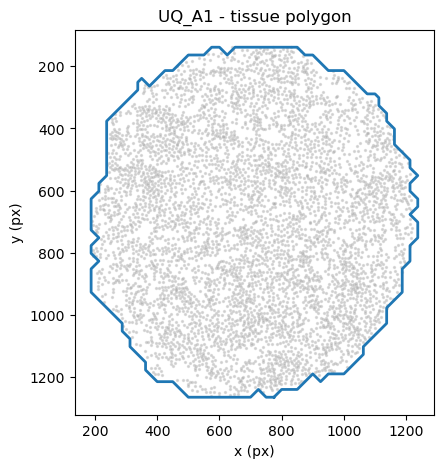

In [10]:
polys = mask_to_polygons(tm, simplify_um=5.0)
print(f"components       : {len(polys)}")
print(f"exterior verts   : {[len(p['exterior']) for p in polys]}")
print(f"polygon area     : {polygon_area_um2(polys, mpp)/1e6:.3f} mm2  "
      f"(grid area {tm.area_mm2:.3f} mm2)")

plt.figure(figsize=(5, 5))
plt.scatter(xy[:, 0], xy[:, 1], s=2, alpha=0.3, c="0.6")
for p in polys:
    e = np.vstack([p["exterior"], p["exterior"][:1]])
    plt.plot(e[:, 0], e[:, 1], "-", lw=2, c="tab:blue")
    for h in p["holes"]:
        hh = np.vstack([h, h[:1]])
        plt.plot(hh[:, 0], hh[:, 1], "-", lw=1, c="tab:orange")
plt.gca().set_aspect("equal"); plt.gca().invert_yaxis()
plt.title(f"{rid} - tissue polygon"); plt.xlabel("x (px)"); plt.ylabel("y (px)")
plt.show()

## 5. Which cell types are tumour cells? (per dataset)

To carve out the tumour compartment we first need to know **which `cell_type` labels are
tumour cells** in each dataset - and the naming is wildly inconsistent. Two regimes:

- **Named tumour panels** - the label literally says tumour/cancer (`Tumor (CK+ HR lo)`,
  `Tumor 3`, `Cancer`, `Tumour`, `PD-L1+ tumor`, ...). A single case-insensitive regex
  (`tumou?r|cancer`) captures *all* tumour subtypes, including proliferating/hypoxic/marker+
  variants.
- **Marker-phenotype panels** (`bc_metabric_ali2020`, `tnbc_wang2023`) - cells are named by
  their marker profile, so there is no "tumour" string; the tumour (malignant epithelial)
  clusters have to be **enumerated explicitly**. These lists are a domain call and are flagged
  `REVIEW` - adjust them if your annotation differs.

`TUMOR_RULES` below encodes both. `tumor_labels(ds)` resolves the rule against a dataset's
actual vocabulary and returns the concrete tumour label set; the audit loop then prints, per
dataset, exactly what was classed tumour vs non-tumour (and flags any unclassified label).

In [11]:
import re

# regex (case-insensitive) applied to the label; or an explicit set for marker panels.
TUMOR_RULES = {
    "bc_jackson2020":       {"regex": r"tumou?r"},
    "crc_schurch2020":      {"regex": r"tumou?r"},   # incl. 'tumor cells / immune cells'
    "crc_wu2022":           {"regex": r"tumou?r"},   # Tumor 1..7
    "hnc_wu2022":           {"regex": r"tumou?r"},
    "luad_sorin2023":       {"regex": r"cancer"},
    "nsclc_aung2025":       {"regex": r"tumou?r"},
    "nsclc_gnn_hoebel2026": {"regex": r"tumou?r"},   # PD-L1+/- tumor
    "nsclc_ici_monkman2024":{"regex": r"tumou?r"},   # incl. Proliferating/HLADR/CD44 Tumour
    # --- marker-phenotype panels: explicit malignant-epithelial label sets (REVIEW) ---
    "bc_metabric_ali2020":  {"labels": {
        "HR+ CK7-", "HR+ CK7- Ki67+", "HR+ CK7- Slug+", "HR- CK7-", "HR- CK7+",
        "HR- Ki67+", "HRlow CKlow", "HR- CKlow CK5+", "Basal CKlow", "HER2+",
        "Myoepithelial", "Hypoxia",
    }},
    "tnbc_wang2023":        {"labels": {
        "panCK^{med}", "CK8/18^{med}", "CK^{hi}GATA3^{+}", "CK^{lo}GATA3^{+}", "Basal",
        "AR^{+}LAR", "CD56^{+}NE", "Vimentin^{+}EMT", "CA9^+", "CA9^{+}Hypoxia",
        "pH2AX^{+}DSB", "Apoptosis",
    }},
}


def dataset_vocab(ds, max_regions=None):
    """Union of cell-type labels across (a sample of) a dataset's regions, with counts."""
    from collections import Counter
    counts = Counter()
    rids = ds.all_region_ids if max_regions is None else ds.all_region_ids[:max_regions]
    for rid in rids:
        ct = pd.read_csv(ds.region_dir(rid) / "cell_types.csv")
        col = ds._cell_type_col if ds._cell_type_col in ct.columns else \
            [c for c in ct.columns if c != "cell_id"][0]
        counts.update(ct[col].astype(str).value_counts().to_dict())
    return counts


def tumor_labels(dataset_key, vocab):
    """Resolve TUMOR_RULES[dataset_key] to the concrete tumour label set present in vocab."""
    rule = TUMOR_RULES.get(dataset_key)
    if rule is None:
        return set()
    if "regex" in rule:
        rx = re.compile(rule["regex"], re.I)
        return {lab for lab in vocab if rx.search(lab)}
    return {lab for lab in vocab if lab in rule["labels"]}


def _cell_type_series(region):
    """The label column of a region (``cell_type`` if present, else the first column).

    Some datasets ship extra columns (``metacluster``, ``cell_type_uniform``, ...), so we
    can't just take column 0.
    """
    cols = region.cell_types.columns
    col = "cell_type" if "cell_type" in cols else cols[0]
    return region.cell_types[col].astype(str)


def is_tumor_cell(region, dataset_key):
    """Boolean over a region's cells: True where the label is a tumour type for this dataset.

    Applies ``TUMOR_RULES[dataset_key]`` directly to the region's labels (regex or explicit
    set), so it needs no precomputed vocabulary and works region-by-region.
    """
    labels = _cell_type_series(region)
    rule = TUMOR_RULES.get(dataset_key)
    if rule is None:
        return np.zeros(len(labels), bool)
    if "regex" in rule:
        return labels.str.contains(rule["regex"], case=False, regex=True).to_numpy()
    return labels.isin(rule["labels"]).to_numpy()

In [10]:
# Audit every dataset: show the tumour vs non-tumour split and flag unclassified labels.
for key in list_datasets():
    d = load_dataset(key, data_root=data_root)
    vocab = dataset_vocab(d)
    rule = TUMOR_RULES.get(key)
    if rule is None:
        print(f"\n### {key}: NO RULE - add one to TUMOR_RULES"); continue
    if "regex" in rule:
        rx = re.compile(rule["regex"], re.I)
        tum = {l for l in vocab if rx.search(l)}
        how = f"regex /{rule['regex']}/i"
    else:
        tum = {l for l in vocab if l in rule["labels"]}
        missing = rule["labels"] - set(vocab)
        how = "explicit labels (REVIEW)" + (f"  [not found: {sorted(missing)}]" if missing else "")
    n_tum = sum(vocab[l] for l in tum)
    n_all = sum(vocab.values())
    print(f"\n### {key}  -  {how}")
    print(f"    tumour cells: {n_tum:,} / {n_all:,}  ({n_tum/n_all:.0%})   labels={len(tum)}/{len(vocab)}")
    print(f"    TUMOUR    : {sorted(tum)}")
    print(f"    non-tumour: {sorted(set(vocab) - tum)}")


### bc_jackson2020  -  regex /tumou?r/i
    tumour cells: 639,020 / 1,224,411  (52%)   labels=14/25
    TUMOUR    : ['Tumor (Apoptotic)', 'Tumor (Basal CK)', 'Tumor (CK lo HR hi p53+)', 'Tumor (CK lo HR lo)', 'Tumor (CK+ HR hi)', 'Tumor (CK+ HR lo)', 'Tumor (CK+ HR+)', 'Tumor (CK7+ CK hi Ecadh hi)', 'Tumor (CK7+)', 'Tumor (Epithelial low)', 'Tumor (Hypoxic)', 'Tumor (Myoepithelial)', 'Tumor (Proliferative)', 'Tumor (p53+ EGFR+)']
    non-tumour: ['B cell', 'Endothelial', 'Macrophage', 'Stroma (Fibronectin hi)', 'Stroma (Large elongated)', 'Stroma (SMA hi Vimentin hi)', 'Stroma (Small circular)', 'Stroma (Small elongated)', 'Stroma (Vimentin hi)', 'T & B cells', 'T cell']



### bc_metabric_ali2020  -  explicit labels (REVIEW)
    tumour cells: 292,481 / 479,844  (61%)   labels=12/22
    TUMOUR    : ['Basal CKlow', 'HER2+', 'HR+ CK7-', 'HR+ CK7- Ki67+', 'HR+ CK7- Slug+', 'HR- CK7+', 'HR- CK7-', 'HR- CKlow CK5+', 'HR- Ki67+', 'HRlow CKlow', 'Hypoxia', 'Myoepithelial']
    non-tumour: ['B cells', 'Endothelial', 'Fibroblasts', 'Fibroblasts CD68+', 'Macrophages Vim+ CD45low', 'Macrophages Vim+ Slug+', 'Macrophages Vim+ Slug-', 'Myofibroblasts', 'T cells', 'Vascular SMA+']

### crc_schurch2020  -  regex /tumou?r/i
    tumour cells: 49,399 / 258,385  (19%)   labels=2/29
    TUMOUR    : ['tumor cells', 'tumor cells / immune cells']
    non-tumour: ['B cells', 'CD11b+ monocytes', 'CD11b+CD68+ macrophages', 'CD11c+ DCs', 'CD163+ macrophages', 'CD3+ T cells', 'CD4+ T cells', 'CD4+ T cells CD45RO+', 'CD4+ T cells GATA3+', 'CD68+ macrophages', 'CD68+ macrophages GzmB+', 'CD68+CD163+ macrophages', 'CD8+ T cells', 'NK cells', 'Tregs', 'adipocytes', 'dirt', 'granulocyte


### crc_wu2022  -  regex /tumou?r/i
    tumour cells: 351,664 / 632,280  (56%)   labels=7/15
    TUMOUR    : ['Tumor 1', 'Tumor 2 (Ki67 Proliferating)', 'Tumor 3', 'Tumor 4', 'Tumor 5', 'Tumor 6 / DC', 'Tumor 7']
    non-tumour: ['B cell', 'Blood vessel', 'CD4 T cell', 'CD8 T cell', 'Granulocyte', 'Macrophage', 'Other', 'Stroma']



### hnc_wu2022  -  regex /tumou?r/i
    tumour cells: 954,004 / 2,301,895  (41%)   labels=8/32
    TUMOUR    : ['Tumor', 'Tumor (CD15+)', 'Tumor (CD20+)', 'Tumor (CD21+)', 'Tumor (Ki67+)', 'Tumor (PanCK hi)', 'Tumor (PanCK low)', 'Tumor (Podo+)']
    non-tumour: ['APC', 'APC/macrophage', 'B cell', 'CD4 T cell', 'CD4 T cell (ICOS+/FoxP3+)', 'CD8 T cell', 'Dendritic cell', 'Granulocyte', 'Lymph vessel', 'Macrophage', 'Mast cell', 'NK cell', 'Naive B cell', 'Naive immune cell', 'Naive lymphocyte (CD45RA+/CD38+)', 'Stroma', 'Stromal / Fibroblast', 'T cell (CD45RO+/FoxP3+/ICOS+)', 'T cell (GranzymeB+/LAG3+)', 'Unassigned', 'Unclassified', 'Unknown (TCF1+)', 'Vessel', 'Vessel endothelium']



### luad_sorin2023  -  regex /cancer/i
    tumour cells: 930,658 / 2,141,875  (43%)   labels=1/17
    TUMOUR    : ['Cancer']
    non-tumour: ['Alt MAC', 'B cell', 'Cl MAC', 'Cl Mo', 'DCs cell', 'Endothelial cell', 'Int Mo', 'Mast cell', 'NK cell', 'NONE', 'Neutrophils', 'Non-Cl Mo', 'T other', 'Tc', 'Th', 'Treg']

### nsclc_aung2025  -  regex /tumou?r/i
    tumour cells: 103,390 / 280,386  (37%)   labels=1/16
    TUMOUR    : ['Tumour']
    non-tumour: ['B_Cells', 'CD4', 'CD4_TFH', 'CD8_cells', 'Cytotoxic CD8', 'DCs', 'Exhausted CD8', 'Granulocytes', 'Ki67', 'M1_mac', 'M2_mac', 'Stroma', 'Treg', 'Unidentified', 'Vessels']



### nsclc_gnn_hoebel2026  -  regex /tumou?r/i
    tumour cells: 3,729,694 / 8,974,951  (42%)   labels=2/8
    TUMOUR    : ['PD-L1+ tumor', 'PD-L1- tumor']
    non-tumour: ['FOXP3+', 'PD-1+ (CD8-)', 'PD-1+ CD8+', 'PD-1- CD8+', 'PD-L1+ immune', 'Unspecified']

### nsclc_ici_monkman2024  -  regex /tumou?r/i
    tumour cells: 76,616 / 210,945  (36%)   labels=4/21
    TUMOUR    : ['CD44 Tumour', 'HLADR Tumour', 'Proliferating Tumour', 'Tumour']
    non-tumour: ['Artifact', 'B Cells', 'Blood Vessels', 'CCR7+ CD8/CD4 Cells', 'CD4 Cells', 'CD8 Cells', 'Effector CD4', 'Granulocytes', 'Lymphatics', 'Lymphocytes', 'Macrophages', 'Mast Cells', 'Monocytes', 'Proliferating Lymphocytes', 'Stroma', 'Treg', 'Unclassified']



### tnbc_wang2023  -  explicit labels (REVIEW)
    tumour cells: 406,928 / 1,003,614  (41%)   labels=12/37
    TUMOUR    : ['AR^{+}LAR', 'Apoptosis', 'Basal', 'CA9^+', 'CA9^{+}Hypoxia', 'CD56^{+}NE', 'CK8/18^{med}', 'CK^{hi}GATA3^{+}', 'CK^{lo}GATA3^{+}', 'Vimentin^{+}EMT', 'pH2AX^{+}DSB', 'panCK^{med}']
    non-tumour: ['CD15^{+}', 'CD20^+B', 'CD4^+PD1^+T', 'CD4^+TCF1^+T', 'CD56^+NK', 'CD79a^+Plasma', 'CD8^+GZMB^+T', 'CD8^+PD1^+T_{Ex}', 'CD8^+T', 'CD8^+TCF1^+T', 'DCs', 'Endothelial', 'Fibroblasts', 'Helios^{+}', 'M2 Mac', 'MHC I&II^{hi}', 'Myofibroblasts', 'Neutrophils', 'PD-L1^+APCs', 'PD-L1^+IDO^+APCs', 'PD-L1^{+}GZMB^{+}', 'PD-L1^{+}IDO^{+}', 'PDPN^+Stromal', 'TCF1^{+}', 'Treg']


## 6. A tumour sub-mask for one region

The tumour compartment is estimated the same way as the tissue foreground, but **seeded only
from tumour cells**, built on the **same grid** as the tissue mask, and finally **clipped to
the tissue mask**. Closing (`close_um`) bridges the gaps where immune/stromal cells sit
*between* tumour cells and `fill_holes` fills tumour-enclosed pockets - so the resulting
region deliberately **contains the non-tumour cells embedded in tumour nests**, while a wider
`close_um` would start swallowing pure-stroma bands between separate nests (a knob to tune).

**Scattered tumour cells** - isolated tumour cells drifting in stroma/immune areas, not part
of any tumour bulk - would otherwise each seed a little island. We drop them *before* masking
with a density (DBSCAN core-point) filter: a tumour cell is kept only if it has at least
`min_neighbors` other tumour cells within `neighbor_radius_um`. Singletons and tiny clusters
fall away; the dense bulk is untouched. (`min_component_mm2` still removes any small blob that
slips through.)

`submask_from_points` reuses the reference mask's grid so the two masks are bit-aligned; the
readout confirms tumour ⊆ tissue and counts the non-tumour cells that fall inside the tumour
region.

In [11]:
def bulk_point_filter(xy_subset, microns_per_pixel, *, min_neighbors=3, radius_um=50.0):
    """Keep only 'core' points: those with >= ``min_neighbors`` others within ``radius_um``.

    A DBSCAN-style density filter that removes scattered / isolated points (e.g. lone tumour
    cells adrift in stroma) while leaving dense clusters intact. Returns a boolean keep-mask
    aligned with ``xy_subset``.
    """
    if min_neighbors <= 0 or len(xy_subset) <= min_neighbors:
        return np.ones(len(xy_subset), bool)
    from scipy.spatial import cKDTree
    r_px = radius_um / microns_per_pixel
    # return_length counts the point itself, so ``> min_neighbors`` == ``>= min_neighbors`` others
    counts = cKDTree(xy_subset).query_ball_point(xy_subset, r_px, return_length=True)
    return counts > min_neighbors


def submask_from_points(reference: TissueMask, xy_subset, *, close_um=50.0,
                        fill_holes=True, min_component_mm2=0.005, clip_to_reference=True,
                        min_neighbors=3, neighbor_radius_um=50.0):
    """Estimate a sub-mask from a subset of points, on ``reference``'s exact grid.

    Sharing the grid (origin, bin size, shape) means the result is bit-aligned with the
    reference mask, so intersection (``clip_to_reference``) and polygon coordinates are
    directly comparable. Same padding trick as :func:`estimate_tissue_mask` avoids the
    edge effect. ``min_neighbors`` / ``neighbor_radius_um`` drop scattered points before
    masking (see :func:`bulk_point_filter`); set ``min_neighbors=0`` to disable.
    """
    keep = bulk_point_filter(xy_subset, reference.microns_per_pixel,
                             min_neighbors=min_neighbors, radius_um=neighbor_radius_um)
    xy_subset = xy_subset[keep]

    ny, nx = reference.mask.shape
    if len(xy_subset) == 0:
        empty = np.zeros((ny, nx), bool)
        return TissueMask(empty, reference.x0, reference.y0, reference.bin_px,
                          reference.bin_um, reference.microns_per_pixel)
    ix = np.floor((xy_subset[:, 0] - reference.x0) / reference.bin_px).astype(int)
    iy = np.floor((xy_subset[:, 1] - reference.y0) / reference.bin_px).astype(int)
    inb = (ix >= 0) & (iy >= 0) & (ix < nx) & (iy < ny)
    occ = np.zeros((ny, nx), bool)
    occ[iy[inb], ix[inb]] = True

    radius_bins = max(1, int(round(close_um / reference.bin_um)))
    pad = radius_bins + 1
    occ = np.pad(occ, pad, mode="constant", constant_values=False)
    structure = ndi.generate_binary_structure(2, 1)
    occ = ndi.binary_closing(occ, structure=structure, iterations=radius_bins)
    if fill_holes:
        occ = ndi.binary_fill_holes(occ)
    occ = occ[pad:-pad, pad:-pad]                 # crop back to the reference grid

    if clip_to_reference:
        occ &= reference.mask

    if min_component_mm2 and occ.any():
        min_bins = max(1, int(min_component_mm2 * 1e6 / (reference.bin_um ** 2)))
        lbl, n = ndi.label(occ)
        if n > 1:
            sizes = np.bincount(lbl.ravel())
            sizes[0] = 0
            occ = np.isin(lbl, np.where(sizes >= min_bins)[0])

    return TissueMask(occ, reference.x0, reference.y0, reference.bin_px,
                      reference.bin_um, reference.microns_per_pixel)

In [12]:
DATASET_KEY = "nsclc_aung2025"
tum_set = tumor_labels(DATASET_KEY, dataset_vocab(ds))
is_tum = is_tumor_cell(reg, DATASET_KEY)
tum_xy = xy[is_tum]

# which tumour cells are 'bulk' (kept) vs 'scattered' (omitted)
is_bulk = bulk_point_filter(tum_xy, mpp, min_neighbors=3, radius_um=50.0)

# with the density filter (default) vs without, to show what the scattered cells contribute
tumor_tm    = submask_from_points(tm, tum_xy)                      # min_neighbors=3
tumor_tm_all = submask_from_points(tm, tum_xy, min_neighbors=0)    # keep every tumour cell
inside_tumor = tumor_tm.contains(xy)

print(f"tumour labels          : {sorted(tum_set)}")
print(f"tumour cells           : {is_tum.sum()} / {len(xy)}")
print(f"  bulk (kept)          : {is_bulk.sum()}")
print(f"  scattered (omitted)  : {(~is_bulk).sum()}")
print(f"tissue area            : {tm.area_mm2:.3f} mm2")
print(f"tumour area (bulk)     : {tumor_tm.area_mm2:.3f} mm2  ({tumor_tm.area_mm2/tm.area_mm2:.0%} of tissue)")
print(f"tumour area (all cells): {tumor_tm_all.area_mm2:.3f} mm2  "
      f"(+{tumor_tm_all.area_mm2 - tumor_tm.area_mm2:.3f} mm2 from scattered specks)")
print(f"tumour subset tissue   : {(tumor_tm.mask & ~tm.mask).sum() == 0}")
print(f"cells in tumour area   : {inside_tumor.sum()}  ->  "
      f"non-tumour inside: {(inside_tumor & ~is_tum).sum()} (immune/stroma in nests)")

tumour labels          : ['Tumour']
tumour cells           : 2200 / 4946
  bulk (kept)          : 2186
  scattered (omitted)  : 14
tissue area            : 0.943 mm2
tumour area (bulk)     : 0.753 mm2  (80% of tissue)
tumour area (all cells): 0.807 mm2  (+0.054 mm2 from scattered specks)
tumour subset tissue   : True
cells in tumour area   : 4104  ->  non-tumour inside: 1926 (immune/stroma in nests)


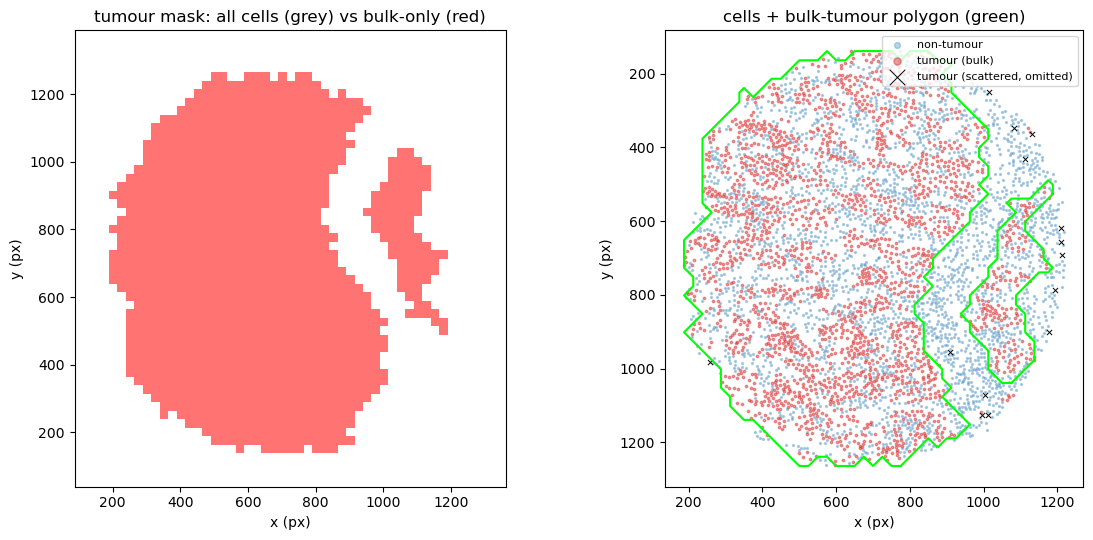

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
extent = [tm.x0, tm.x0 + tm.mask.shape[1] * tm.bin_px,
          tm.y0 + tm.mask.shape[0] * tm.bin_px, tm.y0]

# left: tumour mask WITHOUT the filter (grey) vs WITH it (red) - grey-only bits are the
# scattered-cell islands the density filter removes.
ax[0].imshow(np.ma.masked_where(~tumor_tm_all.mask, tumor_tm_all.mask), extent=extent,
             cmap="Greys", alpha=0.35, origin="upper")
ax[0].imshow(np.ma.masked_where(~tumor_tm.mask, tumor_tm.mask), extent=extent,
             cmap="autumn", alpha=0.55, origin="upper")
ax[0].set_title("tumour mask: all cells (grey) vs bulk-only (red)")

# right: cells coloured (bulk vs scattered tumour) + bulk tumour polygon
tumor_polys = mask_to_polygons(tumor_tm, simplify_um=5.0)
ax[1].scatter(xy[~is_tum, 0], xy[~is_tum, 1], s=2, alpha=0.30, c="tab:blue", label="non-tumour")
ax[1].scatter(tum_xy[is_bulk, 0], tum_xy[is_bulk, 1], s=3, alpha=0.45, c="tab:red", label="tumour (bulk)")
ax[1].scatter(tum_xy[~is_bulk, 0], tum_xy[~is_bulk, 1], s=14, c="k", marker="x",
              linewidths=0.7, label="tumour (scattered, omitted)")
for p in tumor_polys:
    e = np.vstack([p["exterior"], p["exterior"][:1]])
    ax[1].plot(e[:, 0], e[:, 1], "-", lw=1.5, c="lime")
    for h in p["holes"]:
        hh = np.vstack([h, h[:1]])
        ax[1].plot(hh[:, 0], hh[:, 1], "--", lw=1, c="green")
ax[1].set_title("cells + bulk-tumour polygon (green)")
ax[1].legend(markerscale=3, loc="upper right", fontsize=8)
for a in ax:
    a.set_aspect("equal"); a.invert_yaxis(); a.set_xlabel("x (px)"); a.set_ylabel("y (px)")
plt.tight_layout(); plt.show()

## 7. Sampled regions across all datasets

Five regions sampled per dataset (fixed seed for reproducibility). For each we run the full
pipeline and overlay, on a tumour/non-tumour cell scatter, the **tissue-foreground polygon**
(black) and the **tumour sub-mask polygon** (green). Tumour cells are split into **bulk**
(red, kept) and **scattered** (black ×, omitted by the density filter). This is the visual
check that the machinery generalises across panels: the tissue outline hugs the cells, and the
tumour polygon wraps the dense tumour clusters (still enclosing interspersed non-tumour cells)
while ignoring lone tumour cells adrift in stroma. Regions with no tumour bulk show no green
outline.

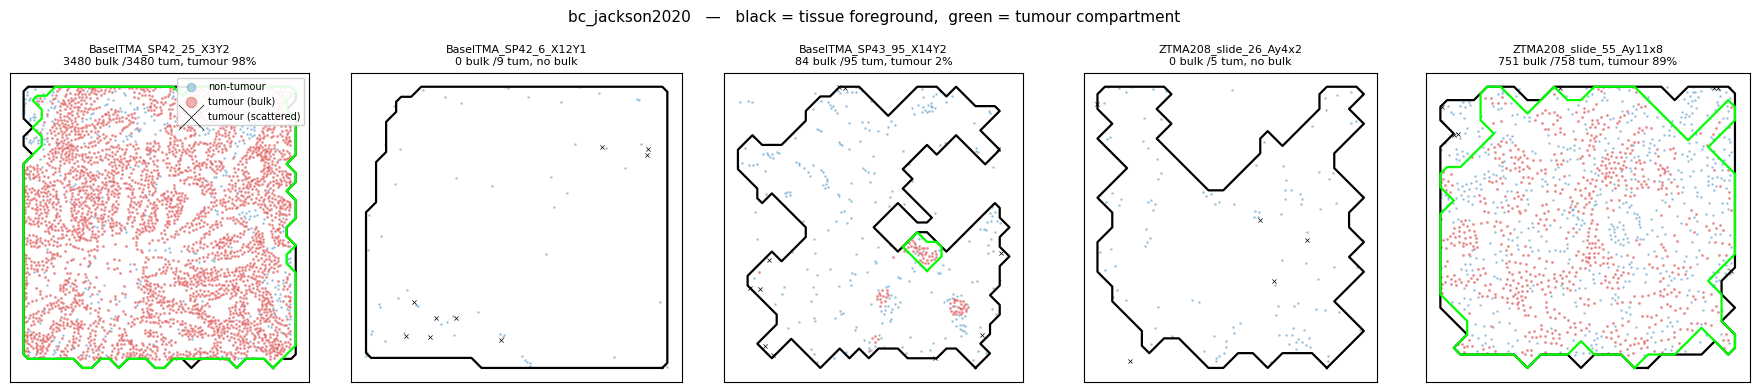

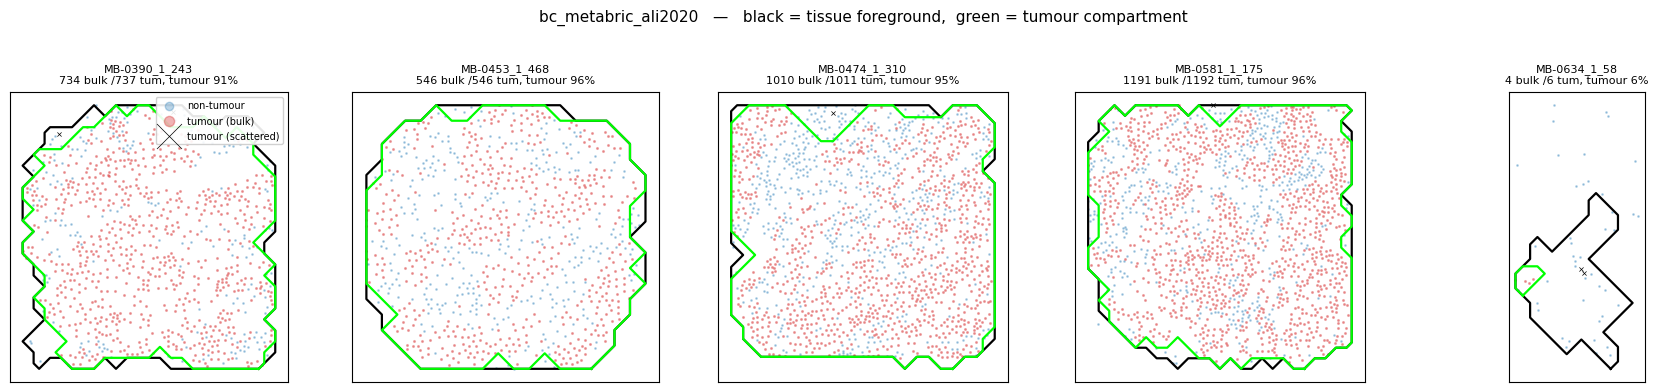

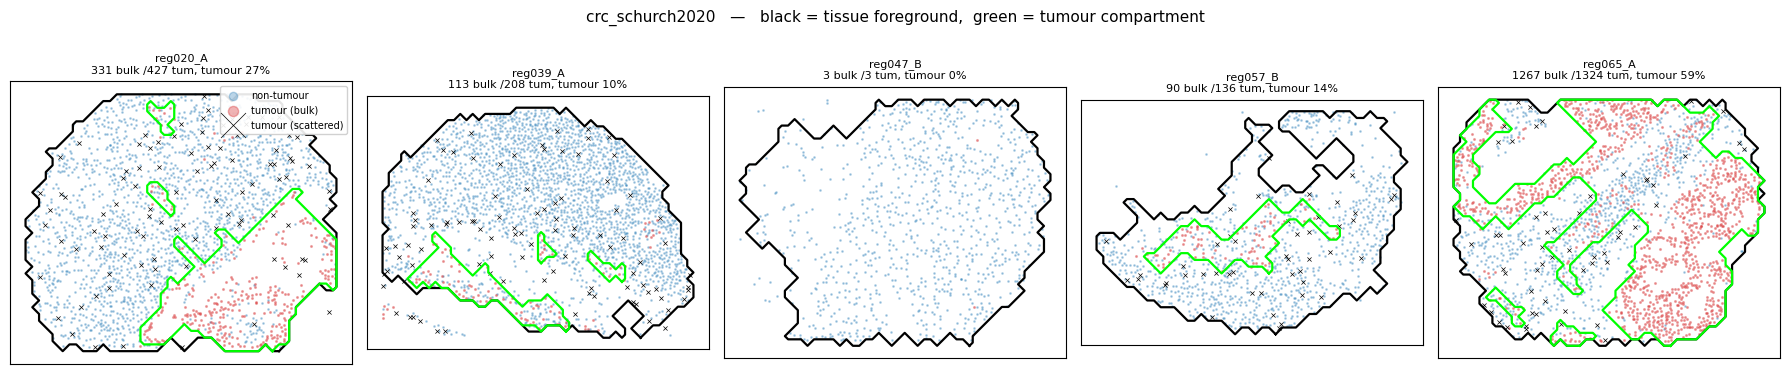

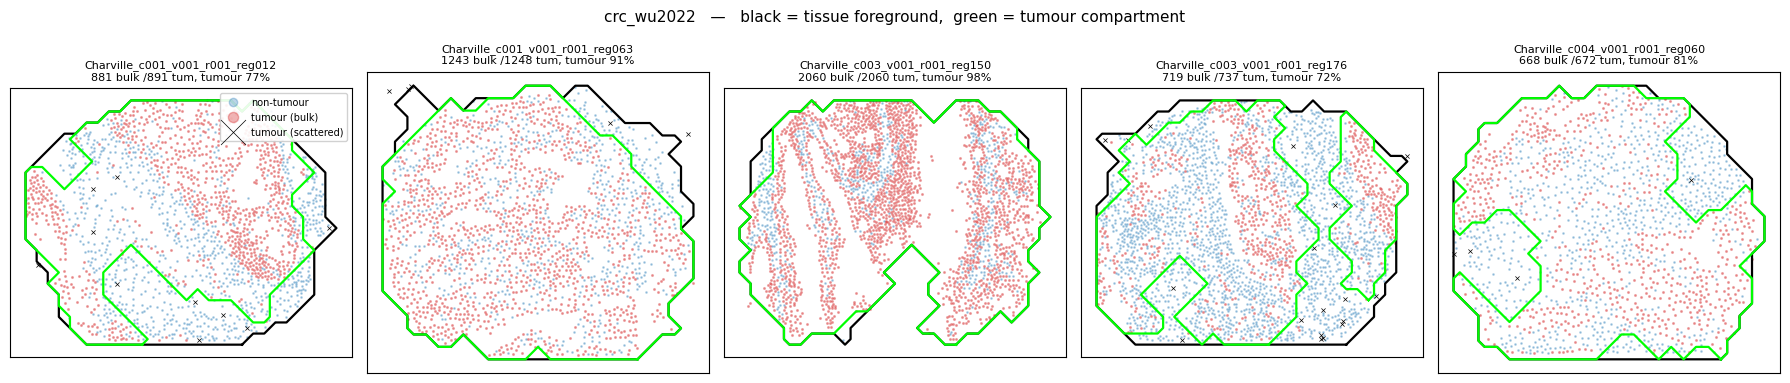

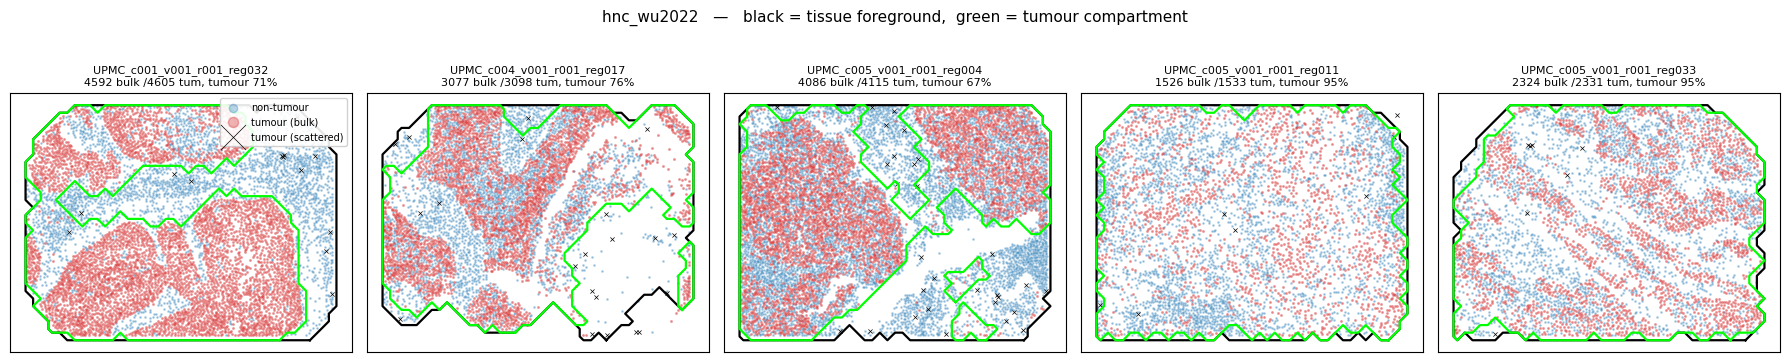

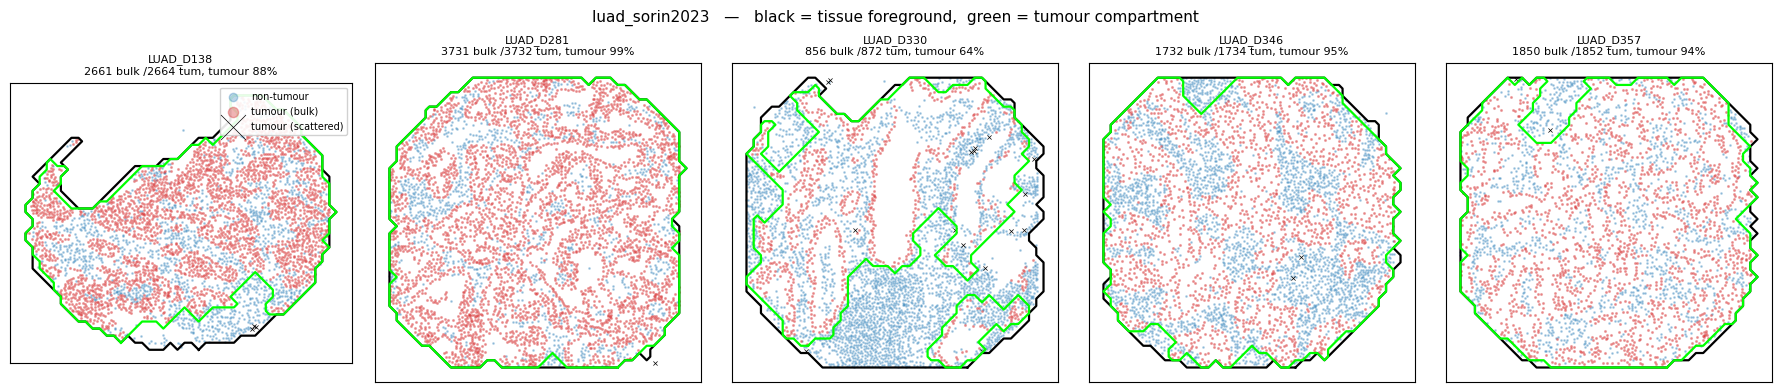

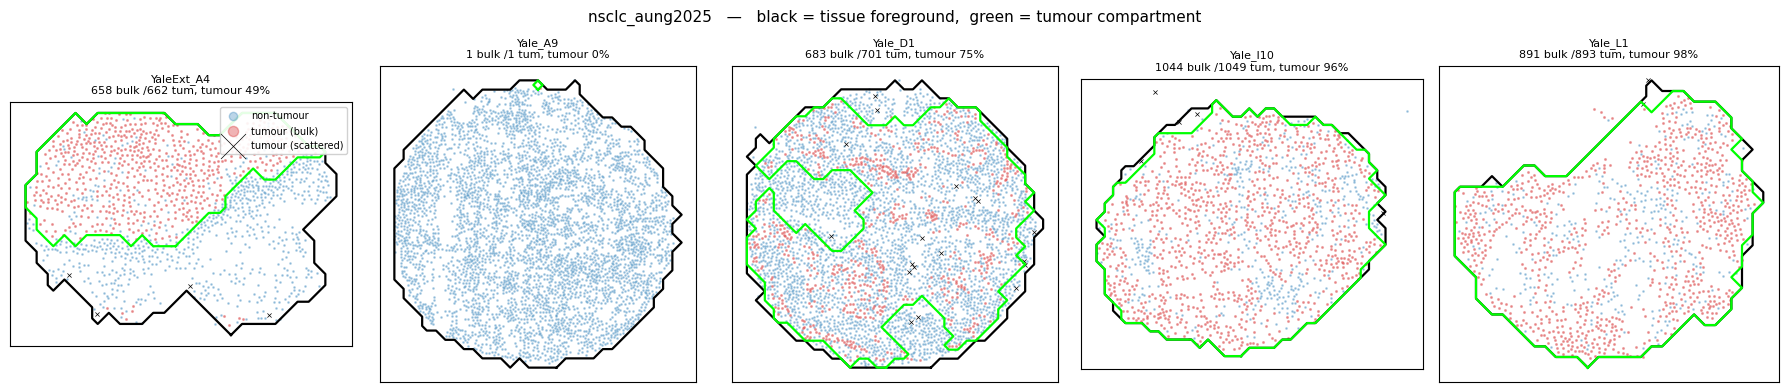

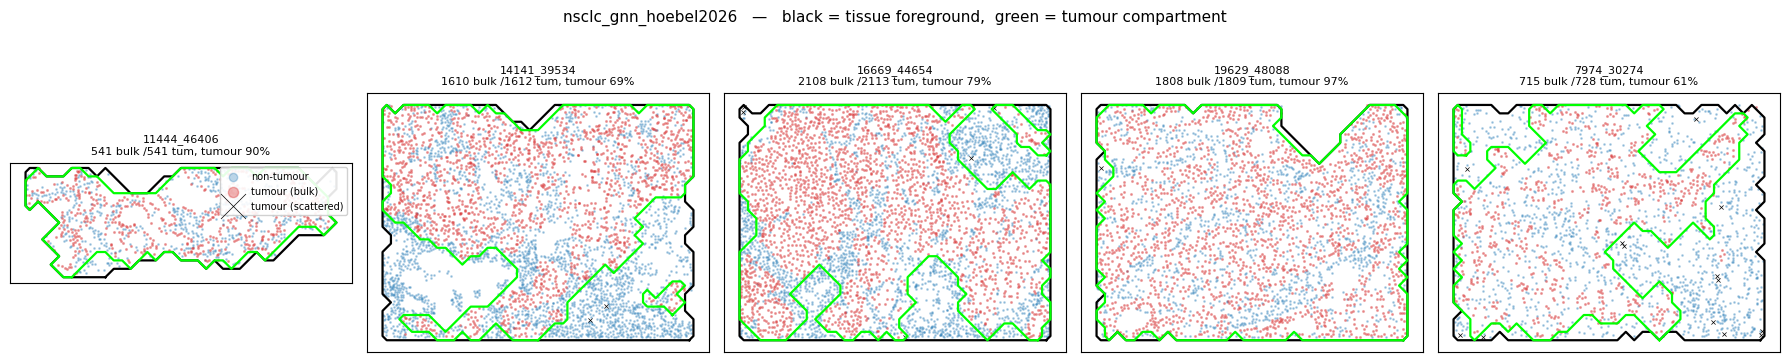

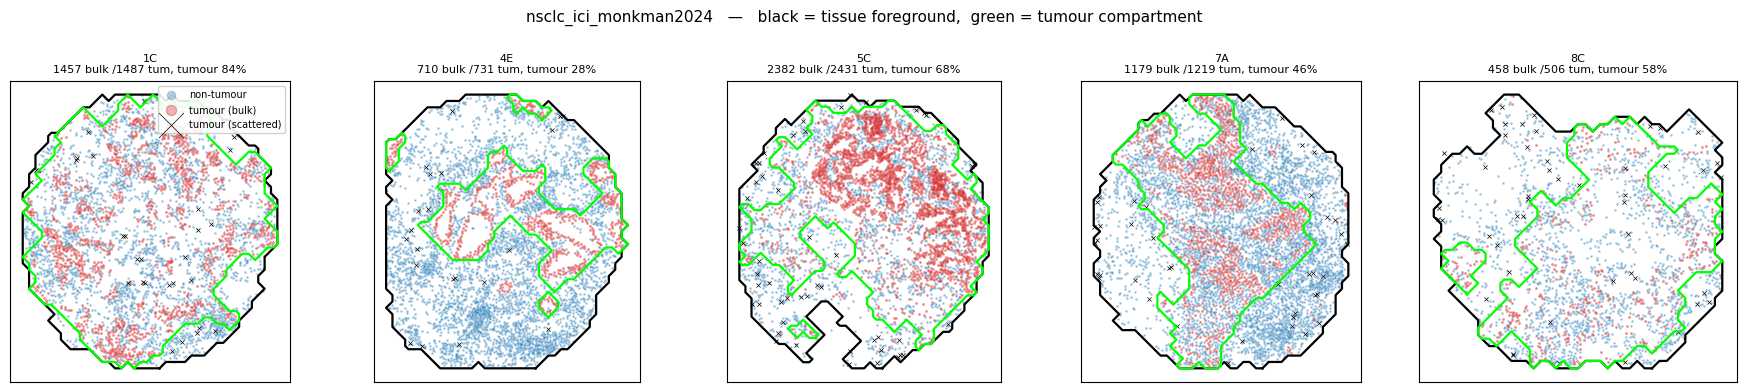

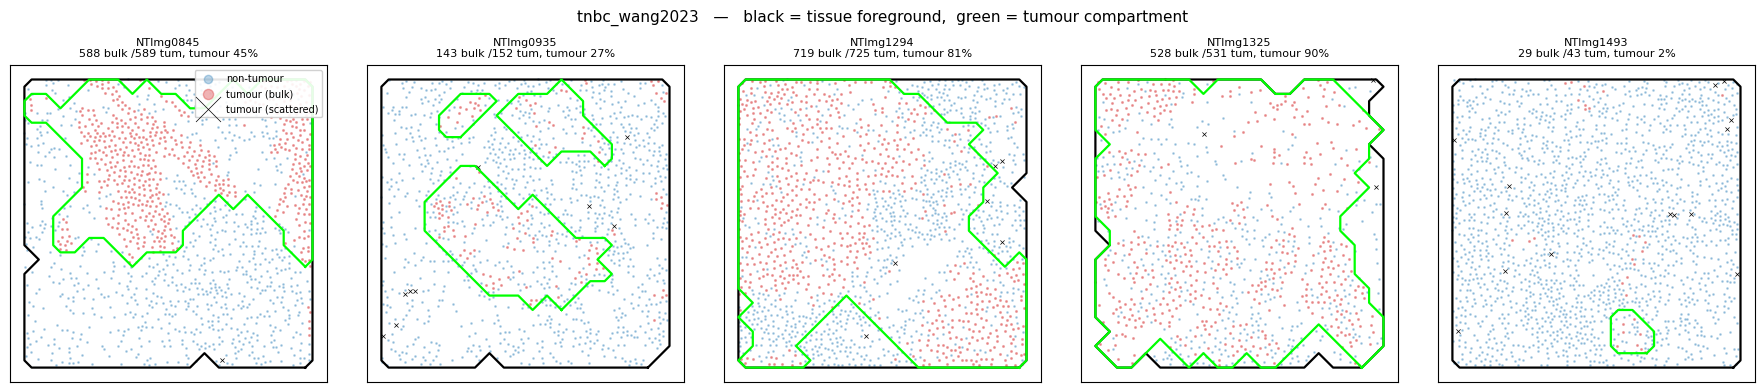

In [14]:
N_SAMPLE = 5
rng = np.random.default_rng(0)

def draw_region(ax, region, dataset_key):
    xy_r = region.coordinates[["x", "y"]].to_numpy(float)
    is_t = is_tumor_cell(region, dataset_key)
    tissue = estimate_tissue_mask(xy_r, region.microns_per_pixel)
    tum_xy = xy_r[is_t]
    is_bulk = bulk_point_filter(tum_xy, region.microns_per_pixel)

    ax.scatter(xy_r[~is_t, 0], xy_r[~is_t, 1], s=1, alpha=0.30, c="tab:blue",
               label="non-tumour", rasterized=True)
    ax.scatter(tum_xy[is_bulk, 0], tum_xy[is_bulk, 1], s=1.5, alpha=0.35, c="tab:red",
               label="tumour (bulk)", rasterized=True)
    ax.scatter(tum_xy[~is_bulk, 0], tum_xy[~is_bulk, 1], s=9, c="k", marker="x",
               linewidths=0.5, label="tumour (scattered)", rasterized=True)

    for p in mask_to_polygons(tissue):                     # foreground (black)
        e = np.vstack([p["exterior"], p["exterior"][:1]]); ax.plot(e[:, 0], e[:, 1], "-", lw=1.6, c="k")
        for h in p["holes"]:
            hh = np.vstack([h, h[:1]]); ax.plot(hh[:, 0], hh[:, 1], "--", lw=0.8, c="0.4")

    tum_frac = np.nan
    if is_bulk.sum() > 0:                                  # tumour compartment (green)
        tumor = submask_from_points(tissue, tum_xy)
        tum_frac = tumor.area_mm2 / tissue.area_mm2 if tissue.area_mm2 else np.nan
        for p in mask_to_polygons(tumor):
            e = np.vstack([p["exterior"], p["exterior"][:1]]); ax.plot(e[:, 0], e[:, 1], "-", lw=1.6, c="lime")
            for h in p["holes"]:
                hh = np.vstack([h, h[:1]]); ax.plot(hh[:, 0], hh[:, 1], "--", lw=0.8, c="green")

    ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([])
    frac_txt = "no bulk" if np.isnan(tum_frac) else f"tumour {tum_frac:.0%}"
    ax.set_title(f"{region.region_id}\n{is_bulk.sum()} bulk /{is_t.sum()} tum, {frac_txt}", fontsize=8)


for key in list_datasets():
    d = load_dataset(key, data_root=data_root)
    rids = d.all_region_ids
    n = min(N_SAMPLE, len(rids))
    sample = sorted(rng.choice(rids, size=n, replace=False).tolist())

    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 3.8))
    axes = np.atleast_1d(axes)
    for ax, rid in zip(axes, sample):
        draw_region(ax, d.load_region(rid, normalize=False), key)
    axes[0].legend(markerscale=6, fontsize=7, loc="upper right", framealpha=0.9)
    fig.suptitle(f"{key}   —   black = tissue foreground,  green = tumour compartment",
                 fontsize=11, y=1.02)
    plt.tight_layout(); plt.show()

## 8. Export polygons for every region, in every dataset

Run the (already-configured) pipeline over **all regions of all datasets** and write the
foreground + tumour polygons to disk. Format is a single **GeoJSON `FeatureCollection`** per
region - the standard, tool-agnostic vector format (readable by shapely / geopandas / QGIS):

- one `Feature` `kind="tissue"` (foreground MultiPolygon), always present;
- one `Feature` `kind="tumour"` (tumour compartment MultiPolygon), present when a tumour bulk
  exists.

Coordinates stay in the region's **pixel space** with `microns_per_pixel` + areas in the
Feature `properties`, so they overlay `coordinates.csv` directly. Vertices are already
simplified by the pipeline; the writer rounds them to 0.1 px, keeping each file to a few KB.
Each file is written as `tissue_polygons.geojson` inside that region's
`processed/.../regions/<REGION_ID>/` folder (i.e. `ds.region_dir(region_id)`).

> Guarded by an env flag so re-running the notebook doesn't rewrite the tree: the full write
> runs only when `RUN_EXPORT_POLYGONS=1` is set in the environment (otherwise the cell just
> previews the format on one region). Nothing else in the pipeline is changed.

In [15]:
import os

def _round_feature(feat, ndigits=1):
    """Round a Feature's coordinates in place to keep the file small."""
    feat["geometry"]["coordinates"] = [
        [[[round(float(x), ndigits), round(float(y), ndigits)] for x, y in ring]
         for ring in poly]
        for poly in feat["geometry"]["coordinates"]
    ]
    return feat


def region_polygons_featurecollection(region, dataset_key):
    """Build the {tissue [, tumour]} GeoJSON FeatureCollection for one region."""
    xy_r = region.coordinates[["x", "y"]].to_numpy(float)
    tissue = estimate_tissue_mask(xy_r, region.microns_per_pixel)
    feats = []
    f_tis = polygons_to_geojson(mask_to_polygons(tissue), tissue, region.region_id)
    f_tis["properties"]["kind"] = "tissue"
    feats.append(_round_feature(f_tis))

    is_t = is_tumor_cell(region, dataset_key)
    if is_t.sum() > 0:
        tumor = submask_from_points(tissue, xy_r[is_t])
        if tumor.mask.any():
            f_tum = polygons_to_geojson(mask_to_polygons(tumor), tumor, region.region_id)
            f_tum["properties"]["kind"] = "tumour"
            feats.append(_round_feature(f_tum))
    return {"type": "FeatureCollection", "features": feats}


def export_all_polygons(filename="tissue_polygons.geojson", datasets=None,
                        overwrite=True, show_progress=True):
    """Write one FeatureCollection file per region across the chosen datasets."""
    keys = datasets or list_datasets()
    n_written, errors = 0, []
    for key in keys:
        d = load_dataset(key, data_root=data_root)
        rids = d.all_region_ids
        it = rids
        if show_progress:
            try:
                from tqdm.auto import tqdm
                it = tqdm(rids, desc=key)
            except ImportError:
                pass
        for rid in it:
            out = d.region_dir(rid) / filename
            if not overwrite and out.exists():
                continue
            try:
                r = d.load_region(rid, normalize=False, use_cache=False)  # no cache: memory
                out.write_text(json.dumps(region_polygons_featurecollection(r, key)))
                n_written += 1
            except Exception as e:                       # keep going; collect failures
                errors.append((key, rid, repr(e)))
    return n_written, errors

In [16]:
if os.environ.get("RUN_EXPORT_POLYGONS") == "1":
    n_written, errors = export_all_polygons()
    print(f"wrote {n_written} files;  {len(errors)} errors")
    for e in errors[:10]:
        print("  ERROR", e)
else:
    demo = region_polygons_featurecollection(reg, DATASET_KEY)
    blob = json.dumps(demo)
    print("dry run - set RUN_EXPORT_POLYGONS=1 to write all region files.")
    print("target path/region :", ds.region_dir(reg.region_id) / "tissue_polygons.geojson")
    print("features           :", [f["properties"]["kind"] for f in demo["features"]])
    print("example size       :", f"{len(blob)/1024:.1f} KB")
    print("tissue properties  :", demo["features"][0]["properties"])

dry run - set RUN_EXPORT_POLYGONS=1 to write all region files.
target path/region : /Users/zhenqin/WORK/TME_benchmark/NSCLC_Aung2025/processed/regions/UQ_A1/tissue_polygons.geojson
features           : ['tissue', 'tumour']
example size       : 3.5 KB
tissue properties  : {'region_id': 'UQ_A1', 'coord_space': 'pixel', 'microns_per_pixel': 1.0, 'bin_um': 25.0, 'area_um2': 943125.0, 'area_mm2': 0.943125, 'kind': 'tissue'}


## 9. Reading a saved GeoJSON back: area, size, plot

How to consume the exported files downstream. GeoJSON is plain JSON, so no special reader is
needed - `json.load` gives nested coordinate lists. Below we (a) load one region's file,
(b) report its on-disk size, (c) recompute each compartment's area with the shoelace formula
(exterior minus holes) and check it against the stored `area_mm2`, and (d) plot the tissue and
tumour polygons over the cell scatter. Coordinates are in pixels; multiply by
`microns_per_pixel` (carried in `properties`) for physical units.

(If you have `shapely`/`geopandas` installed you can instead do
`geopandas.read_file(path)` and get `shapely` geometries with `.area` for free - the file is a
standard FeatureCollection. Here we stay dependency-free.)

In [26]:
ds = load_dataset("nsclc_aung2025", data_root=data_root)
ds.get_metadata().head(3)

,region_id,patient_id,cohort,n_cells,immunotherapy_response,pfs_days,pfs_event,recist,os_days,os_event
0,UQ_A1,UQ_A1,UQ,4946,Responder,NaN,NaN,NaN,NaN,NaN
1,UQ_A2,UQ_A2,UQ,3328,Non-responder,NaN,NaN,NaN,NaN,NaN
2,UQ_A4,UQ_A4,UQ,2599,Responder,NaN,NaN,NaN,NaN,NaN


In [34]:
reg = ds.load_region("UQ_A1")
cell_x, cell_y = reg.coordinates[["x", "y"]].to_numpy(float).T

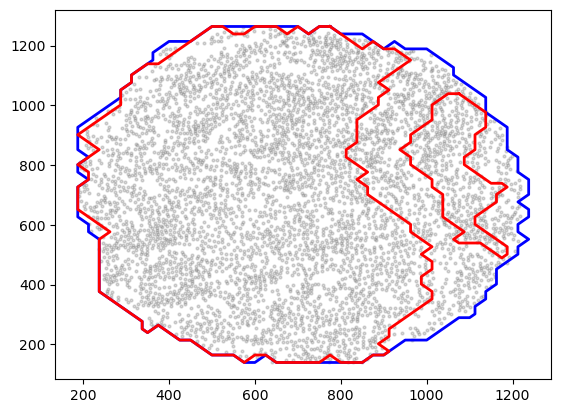

In [40]:

fig, ax = plt.subplots()
ax.plot(cell_x, cell_y, 'o', markersize=2, alpha=0.3, color='grey', label='cells')

# Plot tissue foreground polygons
for geom in reg.polygons['tissue'].geoms:
    # Plot the exterior boundary
    x, y = geom.exterior.xy
    ax.plot(x, y, color='blue', linewidth=2)
    
    for interior in geom.interiors:
        xi, yi = interior.xy
        ax.plot(xi, yi, color='blue', linestyle='--', linewidth=1.5)

## Plot tumour polygons in red
for geom in reg.polygons['tumour'].geoms:
    # Plot the exterior boundary
    x, y = geom.exterior.xy
    ax.plot(x, y, color='red', linewidth=2)
    
    for interior in geom.interiors:
        xi, yi = interior.xy
        ax.plot(xi, yi, color='red', linestyle='--', linewidth=1.5)


---
### Notes & caveats

- **Estimate, not ground truth.** Area is inferred from centroids, so it tracks *segmented*
  tissue. Regions with sparse/failed segmentation under-estimate; `close_um` / `fill_holes`
  control how aggressively gaps are bridged.
- **Tumour labels for marker panels.** `bc_metabric_ali2020` and `tnbc_wang2023` name cells by
  marker profile; the tumour sets in `TUMOR_RULES` are a best-effort domain call flagged
  `REVIEW` - confirm against the paper's phenotype table before relying on them.
- **Tumour = compartment, not cells.** The sub-mask is a *region*: closing + fill_holes make it
  enclose the immune/stromal cells inside tumour nests on purpose. Raise `close_um` to merge
  nearby nests (risks including pure stroma), lower it to hug tumour cells more tightly.
- **Scattered tumour cells are dropped.** The density filter (`min_neighbors` others within
  `neighbor_radius_um`) removes lone tumour cells not part of any bulk before masking. Raise
  `min_neighbors` for a stricter bulk, or set `min_neighbors=0` to keep every tumour cell.
- **Coordinate space.** Everything is in `coordinates.csv` units (pixels for most datasets);
  `microns_per_pixel` does the um conversion. The tumour sub-mask shares the tissue mask's grid,
  so both align cell-for-cell and can be stored/loaded together with `RegionData` later.